In [11]:
# import pandas as pd 
# from scipy import stats 
# from sklearn.datasets import load_iris
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import LabelEncoder
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.decomposition import PCA
# from sklearn.feature_selection import SelectKBest, f_classif


In [12]:
# lets import our dataset from scikit-learn
from sklearn.datasets import load_iris

In [13]:
# lets import pandas to load the dataset as a dataframe
import pandas as pd
iris_flower = load_iris()

# lets load the features dataset 
features = pd.DataFrame(iris_flower.data,columns=iris_flower.feature_names)

# lets load the target dataset
target = iris_flower.target


In [14]:
features.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [15]:
features.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

### **1. Handling missing values**

in most real world datasets missing values might occur in features. you can handle them with imputation techniques such as mean or median inputation

In [16]:
# # lets check for missing  values 

features.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [17]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [18]:
# lets introduce missing values 
features.loc[10,'sepal length (cm)'] = None
features.loc[50:54, 'sepal width (cm)'] = None
features.loc[100:102, "petal length (cm)"] = None


In [19]:
# checking for missing values again..
features.isnull().sum()

sepal length (cm)    1
sepal width (cm)     5
petal length (cm)    3
petal width (cm)     0
dtype: int64

we wil handle the missing values by using simpleInputer

**mote** when using mean as a strategy for imputing your missing value. you have to check if your data is normally distributed if not , median should be your best option to use for a skewed dataset.

for the purpose of this illustration, i am using both mean and median without considering the distribution of the dataset


things to note when preprocessing 
 fit_transform() method 

 it is commonly used in data preprocessing in machine learning, particularly when using tools like scikit-learn for tasks such as imputation, scaling , normalization, or encoding data. it both learns the  parameters and transforms the data in a single steps. this is useful when you want to apply the transformation immediately 


 `fit()` method
 it computes and learns the parameters of the preprocessing technique you are applying. for examample, if you are using a StandardScaler or imputer or training the algorithm, the fit() method calculates the mean or standard deviation of the data.

`transform()` method

it applies the transformation learned by the fit() method to the data

In [20]:
# now lets handle the missing values 

#lets import the imputer library
from sklearn.impute import SimpleImputer



In [21]:
# lets create an instance of the inputer class using mean as strategy for imputation 
impute_mean = SimpleImputer(strategy='mean')

#using median
impute_median = SimpleImputer(strategy='median')


In [22]:
# lets apply the defined instances above 
features[['sepal length (cm)']]= impute_mean.fit_transform(features[['sepal length (cm)']])
features[["sepal width (cm)"]] = impute_mean.fit_transform(features[["sepal width (cm)"]])
features[["petal length (cm)"]] = impute_median.fit_transform(features[["petal length (cm)"]])

In [23]:
features.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

### **2. Handling Outliers**

I believe we should be familiar with outliers by now. Here, I will be introducing us to another method for handling outliers.

Again, let me throw more light on handling outliers. Have you seen a family that everyone of them is tall? But there is this one child who is just "heightly challenged", I mean short. That child is an outlier.

So outliers are data points that are significantly different from other observations in your dataset. They can be unusually high or low values. Think of them as the odd ones out that don't seem to fit the general pattern of the data.

Outliers are not bad in themselves, for the purpose of data analysis or clustering or when building recommender systems or trying to detect anomaly they can be very useful...


But when training a predictive model, they could introduce biases by assigning more weights to those higher values. And this would not help the performance of our model on new dataset.



---


**Methods for Handling Outliers**


To know which of the methods to use, consider domain knowledge, visualize the data to understand the distribution and experiment. Below are method for handling outliers.
1. Removal
2. Capping(Winsorizing or Clipping)

**Outlier Removal**:
To use removal you must have a certain level of knowledge on the field that that data belongs to. If you are not knowledgable about the data, you should at least consult with an expert in that field or speak with the business organization that provided the data. In some cases, outliers in medical records needs a lot of consultation and experimentation with the data before deciding to remove or cap the outliers. Reomval is a drastic approach and you should only use it when you are confident that the outliers are due error or truly represents irrelevant data points.

**Capping**: From our example in data cleaning, the method I used to handle outliers there is the capping method. This method is used when outliers truly represents valid data points but you want to reduce their influences on the model you are building. It preserves more information compared to the removal method.


In our illustration, we will be using Z-score

**How To Manually Calculate Z-score**

This is the formula here.

`Z = {̱X - μ}÷{σ}`

X ⟶ Each data point (observation) in the dataset or selected column

μ ⟶ The mean (average) of the dataset or selected column

σ ⟶ The standard deviation of the dataset column

**How Does Z-Score Work?** _its ok to know it, right?_



Z-score **standardizes** the data by measuring how far X is from the **mean** in terms of **standard deviations**.

When you are done calculating, look through all the Z-score to see anything unusual.

* A Z-score of 0 indicates the value is exactly at the mean.

* A Z-score of +1 indicates the value is one standard deviation above the mean.

* A Z-score of -1 indicates the value is one standard deviation below the mean.

* Any score above 3 and below -3 is considered an outlier, that is, X is an outlier if Z>3 or Z<−3


**Please Note:** That the `stats.zscore()` function calculates the Z-scores for all **numerical column** in a DataFrame by default, but you can choose a specific column as it applies to the dataset you are working with.

In [24]:
features

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [25]:
from scipy import stats
z_scores = stats.zscore(features) # calculate the z-score for the dataframem

# lets print the z-scores
print(z_scores)

[[-9.05163302e-01  1.02053680e+00 -1.34014407e+00 -1.31544430e+00]
 [-1.14773404e+00 -1.44643012e-01 -1.34014407e+00 -1.31544430e+00]
 [-1.39030478e+00  3.21428915e-01 -1.39764453e+00 -1.31544430e+00]
 [-1.51159016e+00  8.83929516e-02 -1.28264361e+00 -1.31544430e+00]
 [-1.02644867e+00  1.25357277e+00 -1.34014407e+00 -1.31544430e+00]
 [-5.41307191e-01  1.95268066e+00 -1.16764268e+00 -1.05217993e+00]
 [-1.51159016e+00  7.87500841e-01 -1.34014407e+00 -1.18381211e+00]
 [-1.02644867e+00  7.87500841e-01 -1.28264361e+00 -1.31544430e+00]
 [-1.75416090e+00 -3.77678975e-01 -1.34014407e+00 -1.31544430e+00]
 [-1.14773404e+00  8.83929516e-02 -1.28264361e+00 -1.44707648e+00]
 [ 0.00000000e+00  1.48660873e+00 -1.28264361e+00 -1.31544430e+00]
 [-1.26901941e+00  7.87500841e-01 -1.22514315e+00 -1.31544430e+00]
 [-1.26901941e+00 -1.44643012e-01 -1.34014407e+00 -1.44707648e+00]
 [-1.87544627e+00 -1.44643012e-01 -1.51264545e+00 -1.44707648e+00]
 [-5.61657085e-02  2.18571662e+00 -1.45514499e+00 -1.31544430e

In [26]:
# lets filter outliers 
#we create a copy of the data set firstt 
handle_outliers_1 = features.copy()
features_with_removed_ouliers =  handle_outliers_1[(abs(z_scores)<3).all(axis=1)]

In [27]:
features_with_removed_ouliers.head(3)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


Capping Method

i am using the numpy function np.where() to create a condition to help apply the capping 

np.where(condition,[x,y])
- The condition: np.abs(z_scores.iloc[:,i])>threshold
- The x: handles_outliers_2[col].clip(lower=outliers.min(),upper=outliers.max())

* The y: `handle_outliers_2[col]`


The condition first convert to absolute values and select all rows(:) in the current column(i) from the (z_scores) DataFrame and check if its greater than the threshhold

The `clip()` method caps both the lower and upper limit if the condition is `True`. Finally, all columns that capping is applied to is returned.


**Note:** I will comment the code alot for better understanding, once you understood it, kindly remove the comments within the code so with can have a clean code.

In [28]:
import numpy as np 

# lets create a copy of our dataframe
handle_outliers_2 = features.copy()

# lets define the threshold first 

threshold = 3 

# lets apply capping to our calculated z-scores
### lets apply a little bit of completely to it incase you are going to be selecting the numeric columns in your own dataset,it works here but doesnt really applies to this case though 
### creating a loop to handle both the limits and the capping of the selected columns

for i,col in enumerate(handle_outliers_2.select_dtypes(include=[np.number]).columns): 
    # lets select the outliers
    outliers = handle_outliers_2[col][np.abs(stats.zscore(handle_outliers_2[col]))> threshold]
    handle_outliers_2[col]= np.where(np.abs(z_scores[:,i]) >threshold,handle_outliers_2[col].clip(lower=outliers.min(),upper=outliers.max()),handle_outliers_2[col]) #using clip

In [29]:
handle_outliers_2.head(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2


In [30]:
# lets import the scaling libraries, take note of how I imported  the library
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [31]:
# Lets standardize the dataset

# lets create a copy of our dataset
standardize_features = features.copy()
# create an instance of the standardScaler class

scaler = StandardScaler()
# lets say youwant to apply it to a particular column
#standardized_sepal_length = scaler.fit_transform(standardized_features[["sepal length (cm)"]])

# But I am applying it to the whole dataset
standard_features = scaler.fit_transform(standardize_features)

In [32]:
normalize_features = features.copy()

normalizer = MinMaxScaler()

normal_features = normalizer.fit_transform(normalize_features)

In [33]:
#import the train_test_split() function --> The name is quite intuitive
from sklearn.model_selection import train_test_split

# Lets make a copy of our dataset
feature_data = features.copy()
target_data = target.copy()

# Lets split the data --> Take time to understand the arrangement of the variable names and their font cases
X_train, X_test, y_train, y_test = train_test_split(feature_data, target_data, test_size=0.3, random_state=234)

# LEts print the shape of the features
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

print("")
# Lets print for the target - which should be a single column
print(f"Training set size: {y_train.shape}")
print(f"Test set size: {y_test.shape}")

Training set size: (105, 4)
Test set size: (45, 4)

Training set size: (105,)
Test set size: (45,)


### **4. Feature Selection**


Feature selection methods are often chosen based on the specific task, model, and dataset characteristics.

When you want to train an algorithm for a model -not all features are relevant to the target variable, and we may want to remove irrelevant ones. This is where feature selection comes in.

If we are to select the features manually, it will require a strong domain expertise. Aside this, there are quite a number of methods that can be leveraged to get the relevant features. Some of the methods are listed below we will treat the last, and if time permits, we might check out the first two in our model training class.

**1. Embeded Method**

**2. Wrapper Method**

**3. Filter Method** : The filter methods evaluate the relevance of features based on their *statistical properties*, independently of the machine learning model, below are examples.
* Correlation - Features/Independent variables with low correlation coefficient tends to be good features for regression

* Chi-square - This used with categorical features, its tests the independence of a feature with respect to target variable.

* Mutual Information  - Measures the dependency between two variables, with higher values indicating a stronger relationship
* ANOVA -

Lets try illustrating with ANOVA...

Note: Chi-square, mutual information and ANOVA uses the same library, but with slight differences..

import the class from  the sklearn library

``
from sklearn.feature_selection import SelectKBest, f_classif
``

`f_classif` - This is a scoring function designed for classification tasks. It uses **ANOVA**'s F-value to assess the relationship between features and target data. After it has done the calculation the higher F-values indicate strong relationship while the lower indicates weak relationship.


`SelectKBest()` - This will select the top k features based on a specified scoring function(`f_classif`). It will now rank the features according to their scores and keep the ones with the highest scores. Then the numbers indicated `k` values are returned (the selected best values)



In [34]:
# Lets import the class for feature selection
from sklearn.feature_selection import SelectKBest, f_classif

In [35]:
# Lets make a copy of the dataset
selection_features = features.copy()
selection_target = target.copy()

# LEts create an instancce of SelectKBest()
best_features = SelectKBest(score_func=f_classif, k=3) # I am pick 3 for K since we only have 4 features
selected_best_features = best_features.fit_transform(selection_features, selection_target)

# lets check the shape of the selected features
selected_best_features. shape


(150, 3)

### **5. Dimensionality Reduction**


Have tried listening to someone recounting an event, and you hear the person say, "*to cut the long story short, let me just tell you what happened*".The person is in a way saying, let's just filter out the unimportant details...

When it comes to dimensionality reduction, it has to do with keeping out or filtering out the unimportant features(dimensions) to keep the import onces only, but it does it without loosing out the import information. Hence, will retain the features that will contribute most to the training.

Dimensionality reduction helps;
1. Understand and visualize  the data in a more manageable way.
2. For faster computation during model training.
3. With improved model performance.

so it is more like i want to summarize the whole thing but i would still have successfully told the story and you would still get the whole thing even though some information have been left out because i feel it is not affecting the point i am driving at

**Techniques used for Dimensionality Reduction**

1. Linear Discriminant Analysis (LDA): Specifically designed for classification problems, it finds dimensions that best separate different classes.

2. t-Distributed Stochastic Neighbor Embedding (t-SNE): Focuses on preserving the local structure of your data, making it useful for visualization.

3. Principal Component Analysis (PCA): Finds the directions of greatest variance in your data and creates new variables (principal components) along those directions.

In [36]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt 

In [37]:
digits= load_digits()

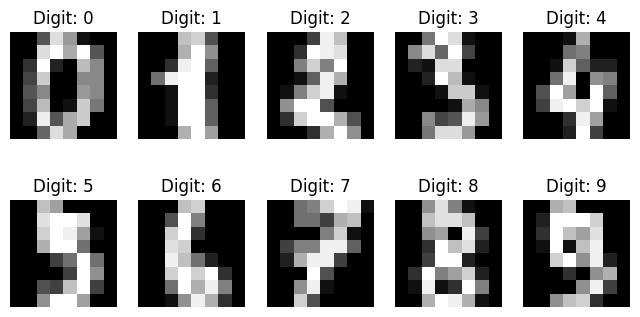

In [38]:
fig,axes = plt.subplots(2,5,figsize=(8,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i],cmap='gray')
    ax.set_title(f'Digit: {digits.target[i]}')
    ax.axis('off')
plt.show()

In [39]:
# The data is in array format, lets convert to pandas dataframe to have a better view
X = digits.data  # Features (64-dimensional)
y = digits.target  # Labels (0-9)

In [40]:
# Convert the data to pandas dataframe and series
X = pd.DataFrame(X)
y = pd.Series(y)

In [41]:
X.head()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [42]:
X.columns

RangeIndex(start=0, stop=64, step=1)

In [43]:
print(f"The rows is: {X.shape[0]}")
print(f"The columns is: {X.shape[1]}")

The rows is: 1797
The columns is: 64


In [44]:
# Lets make a copy of X
X_dimensions = X.copy()

# Create an instance of your PCAC() class and choose the numbers of your principal compoents
# choose the numbers ofyour principal components(n_components)
pc = PCA(n_components=6)

# fit and transform the features to reflect the reduced dimensions
Reduced_X_Dimensions = pc.fit_transform(X_dimensions)

In [45]:
Reduced_X_Dimensions.shape

(1797, 6)

In [46]:
print(Reduced_X_Dimensions)

[[-1.25946645e+00 -2.12748835e+01  9.46305462e+00 -1.30141887e+01
   7.12882278e+00  7.44065876e+00]
 [ 7.95761130e+00  2.07686990e+01 -4.43950604e+00  1.48936644e+01
  -5.89624878e+00  6.48562213e+00]
 [ 6.99192297e+00  9.95598641e+00 -2.95855808e+00  1.22883024e+01
   1.81260233e+01  4.50766373e+00]
 ...
 [ 1.08012837e+01  6.96025223e+00 -5.59955453e+00  7.22773348e+00
   3.45964589e+00  1.23752041e+01]
 [-4.87210009e+00 -1.24239536e+01  1.01708664e+01  6.66885049e+00
  -3.56906108e+00  3.89671361e-03]
 [-3.44389631e-01 -6.36554919e+00 -1.07737085e+01  7.72621321e+00
   3.31061536e+00  3.04906344e+00]]


Using PCA() our features have been reduced from `64 features`  to `6 feature` and still keeping the relevant information of the dataset.

In [ ]:

# LEts plot a scatter plot for our PCA results
# We will plot our first and second PCs  to see their relatedness
plt.figure(figsize=(8,6))
plt.scatter(Reduced_X_Dimensions[:, 0],Reduced_X_Dimensions[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.colorbar(label="Digit Class")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Digits Dataset")
plt.show()